<a href="https://colab.research.google.com/github/Jhay11six/A-B-Test/blob/main/AB_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import io
import seaborn as sns
sns.set()

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving iap.csv to iap.csv
Saving daily_activity.csv to daily_activity.csv
Saving ads.csv to ads.csv
Saving matches.csv to matches.csv


In [ ]:
# Loading the files
verification_df = pd.read_csv(io.BytesIO(uploaded['verification.csv']))
profiles_df = pd.read_csv(io.BytesIO(uploaded['profiles.csv']))
costs_df = pd.read_csv(io.BytesIO(uploaded['costs.csv']))


KeyError: 'verification.csv'

In [ ]:
# Merge profiles with verification data using userID
merged_df = profiles_df.merge(verification_df, on='userID', how='left')

# Merge the result with country cost data using country/Country
final_df = merged_df.merge(costs_df, left_on='country', right_on='country', how='left')

display(final_df)


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,M,"25 Oct, 2005, 00:00",CA,A,Sms,1,0.043,0.007600
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,M,"10 Jun, 1978, 00:00",CA,C,Whatsapp,1,0.043,0.007600
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,F,"15 Feb, 2002, 00:00",GB,A,Sms,1,0.039,0.028740
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,F,"25 Aug, 2001, 00:00",FR,C,Whatsapp,1,0.068,0.033000
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,M,"18 Apr, 1990, 00:00",FR,B,Sms,1,0.068,0.033000
...,...,...,...,...,...,...,...,...,...
18419,mpr_2fNcYCR0mQkxFQk3Ec7iGxlqIfm,M,"21 Apr, 1994, 00:00",GB,C,Whatsapp,1,0.039,0.028740
18420,mpr_2fMhNj8A3PCNVrCO96nddRNXMOy,M,"3 Dec, 1983, 00:00",FR,B,Sms,1,0.068,0.033000
18421,mpr_2fMvy8DguUmyKMAic4dkmGMgmdO,M,"20 Apr, 2006, 00:00",SO,B,Sms,1,0.043,0.181044
18422,mpr_2fN7KDgT4uZwKJBUVSDt1bk5Ctj,M,"14 Apr, 1996, 00:00",US,B,Sms,1,0.043,0.007600


In [ ]:
import datetime

# Convert 'dob' to datetime objects
final_df['dob'] = pd.to_datetime(final_df['dob'], format='%d %b, %Y, %H:%M')

# Calculate age in full years
now = pd.Timestamp(datetime.datetime.now())
final_df['age'] = now.year - final_df['dob'].dt.year

# Adjust age if birthday hasn't occurred yet this year
# This makes the age calculation more precise
final_df['age'] = np.where(
    final_df['dob'].dt.dayofyear > now.dayofyear,
    final_df['age'] - 1,
    final_df['age']
)

print("DataFrame with 'age' column:")
display(final_df[['userID', 'dob', 'age']].head())

DataFrame with 'age' column:


,userID,dob,age
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,2005-10-25,20
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,1978-06-10,47
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,2002-02-15,24
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,2001-08-25,24
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,1990-04-18,35


In [ ]:
#Bin Age

final_df['age_group'] = pd.cut(final_df['age'],
                                    bins=[18,24,34,44,54,64,100],
                                    labels=['18-24','25-34','35-44','45-54','55-64','65-100'],
                                    right=True,
                                    include_lowest=True)


final_df.head()

,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd,age,age_group
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,M,2005-10-25,CA,A,Sms,1,0.043,0.00760,20,18-24
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,M,1978-06-10,CA,C,Whatsapp,1,0.043,0.00760,47,45-54
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,F,2002-02-15,GB,A,Sms,1,0.039,0.02874,24,18-24
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,F,2001-08-25,FR,C,Whatsapp,1,0.068,0.03300,24,18-24
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,M,1990-04-18,FR,B,Sms,1,0.068,0.03300,35,35-44


In [ ]:
# Update columns 'whatsapp_usd' and 'sms_usd' based on the method and verified status.
final_df.loc[final_df['verified'] == 0, ['sms_usd', 'whatsapp_usd']] = 0
# When method is Sms and verified = 1 → whatsapp_usd = 0
final_df.loc[(final_df['method'] == 'Sms') & (final_df['verified'] == 1), 'whatsapp_usd'] = 0
# When method is Whatsapp and verified = 1 → sms_usd = 0
final_df.loc[(final_df['method'] == 'Whatsapp') & (final_df['verified'] == 1), 'sms_usd'] = 0
final_df.head(246)

,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd,age,age_group
0,mpr_2fOzSxcEMql0TQkeK2vGCuJBu9K,M,2005-10-25,CA,A,Sms,1,0.000,0.00760,20,18-24
1,mpr_2fIcL4JraEe6OMdD4xvfVIZiAx8,M,1978-06-10,CA,C,Whatsapp,1,0.043,0.00000,47,45-54
2,mpr_2fHMFzUtfSXQORtB5anUIjuNQso,F,2002-02-15,GB,A,Sms,1,0.000,0.02874,24,18-24
3,mpr_2fHaKh68oUhLyEZwztVzaCHefQ9,F,2001-08-25,FR,C,Whatsapp,1,0.068,0.00000,24,18-24
4,mpr_2fIJtYAsOQ8AqU402d8j5yEFLqt,M,1990-04-18,FR,B,Sms,1,0.000,0.03300,35,35-44
...,...,...,...,...,...,...,...,...,...,...,...
241,mpr_2fN3061cwY47G0ig554LMaVsIS8,M,2003-03-08,DZ,A,Sms,1,0.000,0.13000,23,18-24
242,mpr_2fKqMXBSF3CHSpjpCPBi33DJYzQ,F,1991-08-23,FR,B,Sms,1,0.000,0.03300,34,25-34
243,mpr_2fN2P2kfXZYR1DVAM2eQwHHTl7v,F,1992-12-27,DZ,A,Sms,1,0.000,0.13000,33,25-34
244,mpr_2fEe6dzK5EVFuyZkqCYqOZoNzSq,F,1997-04-22,GB,C,Sms,0,0.000,0.00000,28,25-34


In [ ]:
final_df.loc[(final_df['verified'] == 0)]


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd,age,age_group
126,mpr_2fFVqRGmgalLpIvyAv4mtqv2Kfa,F,2001-10-23,MA,B,Sms,0,0.0,0.0,24,18-24
244,mpr_2fEe6dzK5EVFuyZkqCYqOZoNzSq,F,1997-04-22,GB,C,Sms,0,0.0,0.0,28,25-34
367,mpr_2fOEvv19DhMLGhp1kjTJeyNhpdt,F,2003-06-01,PH,A,Sms,0,0.0,0.0,22,18-24
610,mpr_2fN3WW1IpjG6VjcfDsaR8UAsR0W,M,1991-01-07,DE,B,Sms,0,0.0,0.0,35,35-44
611,mpr_2fNEmEXFnrw7af0K5jo0BRcenoN,M,2000-04-19,DZ,C,Whatsapp,0,0.0,0.0,25,25-34
...,...,...,...,...,...,...,...,...,...,...,...
18025,mpr_2fJ7QiT2m3eI8ucaAdkYFnxJuzB,M,2002-08-02,EG,C,Whatsapp,0,0.0,0.0,23,18-24
18026,mpr_2fJkQ2MZCmD6XxTgthZZFruCIMO,F,2000-10-08,MA,A,Sms,0,0.0,0.0,25,25-34
18027,mpr_2fKAAOR5p7TD2SHJr5cwn2yzYVG,M,2006-04-19,PK,A,Sms,0,0.0,0.0,19,18-24
18028,mpr_2fKLSBuXt70S30FExYkrCTm3QqR,M,2006-04-18,IN,A,Sms,0,0.0,0.0,19,18-24


In [ ]:
# Displaying missing values if there's

print("Missing values in final_df:")
display(final_df.isnull().sum())

Missing values in final_df:


,0
userID,0
gender,0
dob,0
country,3
group,0
method,0
verified,0
whatsapp_usd,1
sms_usd,1
age,0


In [ ]:
# Kindly note the country entries that displayed "NaN" are original NA (which may stand for Namibia) but python saw it as Not available
# I'll have to rename even though there's no whatsapp or sms cost attached to it

print("Rows with missing 'country' values:")
display(final_df[final_df['country'].isnull()])

Rows with missing 'country' values:


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd,age,age_group
308,mpr_2fMRl7NrXhXuM8ahHKpUYYoq1qZ,M,2003-12-20,NaN,B,Whatsapp,1,NaN,0.0,22,18-24
10810,mpr_2fF489IMIBWqhDlQYzIzGrolOhM,F,1988-04-16,NaN,A,Sms,0,0.0,0.0,37,35-44
11674,mpr_2fN0uUj3O9ywDBGrjtW1mNoU3si,M,1983-05-08,NaN,A,Sms,0,0.0,0.0,42,35-44


In [ ]:
print("Rows with missing 'sms_usd' values:")
display(final_df[final_df['sms_usd'].isnull()])

Rows with missing 'sms_usd' values:


,userID,gender,dob,country,group,method,verified,whatsapp_usd,sms_usd,age,age_group
595,mpr_2fF5lozvp4IBEBsTOQwPg9l7NKS,F,1993-10-18,IM,A,Sms,1,0.0,NaN,32,25-34


**Data Cleaning** **Process**

In [ ]:
# Replace all NaN / missing values with 0
# Replace all assumed NaN country to "Na_x"

final_df['sms_usd'] = final_df['sms_usd'].fillna(0)
final_df['whatsapp_usd'] = final_df['whatsapp_usd'].fillna(0)
final_df['country'] = final_df['country'].fillna('Na_x')
# Confirm that there are no missing values left
print(final_df.isna().sum())

userID          0
gender          0
dob             0
country         0
group           0
method          0
verified        0
whatsapp_usd    0
sms_usd         0
age             0
age_group       0
dtype: int64


## **Exploratory Data Analysis (EDA)**

,group,sms_usd,whatsapp_usd
0,A,0.101042,NaN
1,B,0.09886,0.041445
2,C,0.080161,0.043721


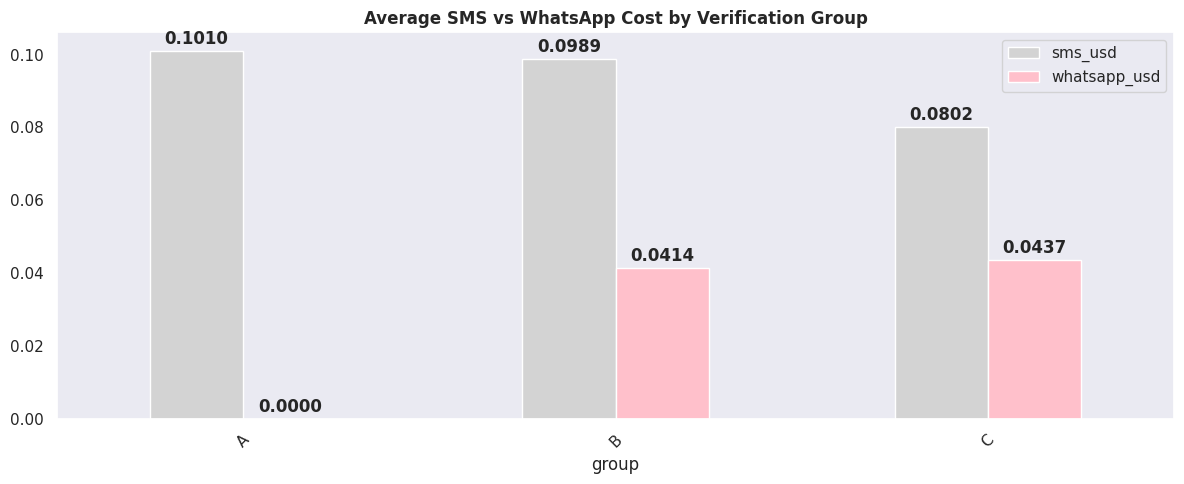

In [ ]:
filtered_df = final_df[final_df['verified'] != 0].copy()

# Remove artificial zeros
filtered_df['sms_usd'] = filtered_df['sms_usd'].replace(0, pd.NA)
filtered_df['whatsapp_usd'] = filtered_df['whatsapp_usd'].replace(0, pd.NA)

avg_cost_by_group = (
    filtered_df.groupby('group')[['sms_usd', 'whatsapp_usd']]
    .mean()
    .reset_index()
    .sort_values(by='sms_usd', ascending=False)
)

display(avg_cost_by_group)

ax = avg_cost_by_group.plot(
    x='group',
    kind='bar',
    figsize=(12,5),
    color=['lightgrey', 'pink']
)

ax.set_title('Average SMS vs WhatsApp Cost by Verification Group', fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=2, fontweight='bold')

ax.grid(False)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Group by 'age' and count 'userID'
user_count_by_age = (
    final_df.groupby('age')['userID']
    .count()
    .reset_index(name='User_Count')
)

# Display the result
print("User count by Age:")
display(user_count_by_age.head())

User count by Age:


,age,User_Count
0,19,191
1,20,984
2,21,872
3,22,926
4,23,999


,age_group,User_Count
0,18-24,5062
1,25-34,9565
2,35-44,2894
3,45-54,715
4,55-64,152
5,65-100,36


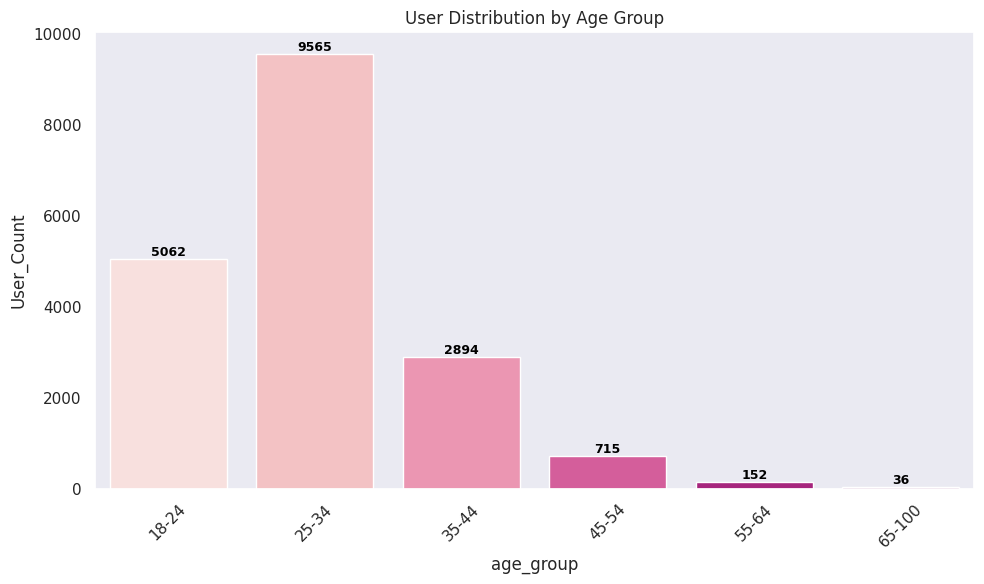

In [ ]:
#User_count by Age_group

user_count_by_age_group = (
    final_df.groupby('age_group', observed=False)['userID']
    .count()
    .reset_index(name='User_Count')
)

display(user_count_by_age_group)

plt.figure(figsize=(10,6));
ax = sns.barplot(x='age_group', y='User_Count', data=user_count_by_age_group, hue='age_group', palette='RdPu', legend=False);
# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', color='black', fontsize=9, fontweight='bold')
ax.grid(False)
plt.title('User Distribution by Age Group');
plt.xticks(rotation=45);
plt.tight_layout();
plt.show()

In [ ]:
#User count by Country

user_count_by_country = (
    final_df.groupby('country')['userID']
    .count()
    .reset_index(name='User_Count')
    .sort_values(by='User_Count', ascending=False)
)

print("User count by Country:")
display(user_count_by_country.head())

User count by Country:


,country,User_Count
92,MA,2037
51,FR,1589
119,PK,1570
150,US,1311
67,ID,1162


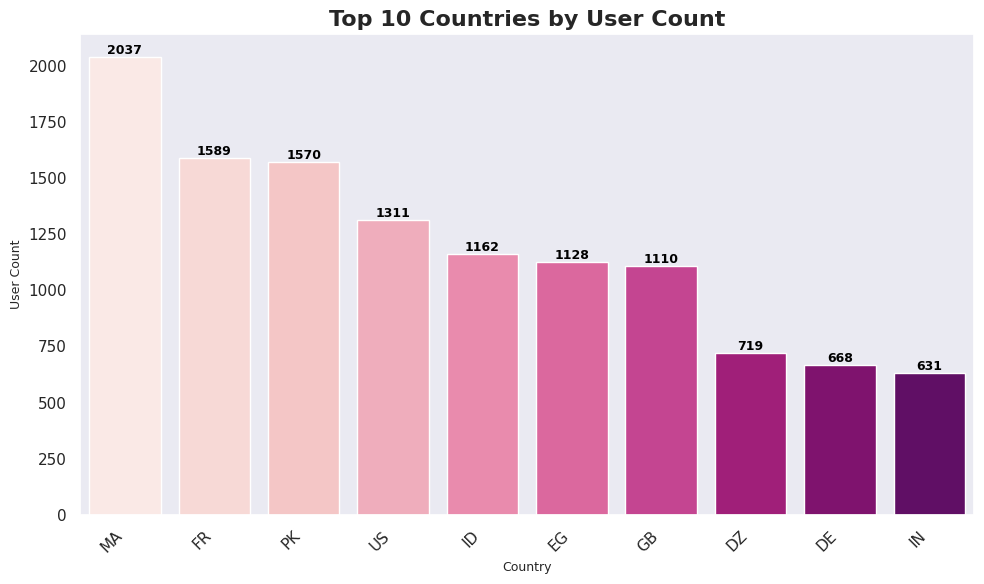

In [ ]:
# Select the top 10 countries
top_10_countries = user_count_by_country.head(10)
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x='country',
    y='User_Count',
    data=top_10_countries,
    hue='country', palette='RdPu', legend=False
)

plt.title('Top 10 Countries by User Count', fontsize=16,fontweight='bold')
plt.xlabel('Country', fontsize=9)
plt.ylabel('User Count', fontsize=9)
plt.xticks(rotation=45, ha='right')

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', color='black', fontsize=9, fontweight='bold')

ax.grid(False)
plt.tight_layout()
plt.show()

,gender,User_Count,Percentage
0,F,7037,38.19
1,M,11387,61.81


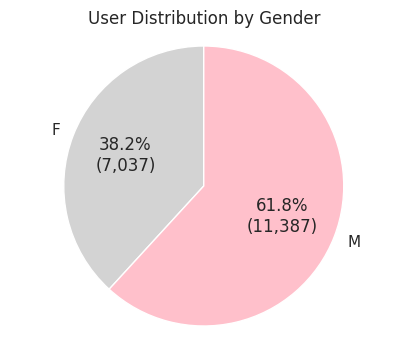

In [ ]:
#User Distribution by Gender

user_count_by_gender = (
    final_df.groupby('gender')['userID']
    .count()
    .reset_index(name='User_Count')
    .assign(Percentage=lambda df: (df['User_Count'] / df['User_Count'].sum() * 100).round(2))
)

display(user_count_by_gender)

plt.figure(figsize=(5,4));
plt.pie(user_count_by_gender['User_Count'], labels=user_count_by_gender['gender'], autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*user_count_by_gender['User_Count'].sum())):,})", colors=['lightgrey', 'pink'],startangle=90);
plt.title('User Distribution by Gender');
plt.axis('equal');
plt.show()

,group,User_Count,Percentage
0,A,6382,34.64
2,C,6118,33.21
1,B,5924,32.15


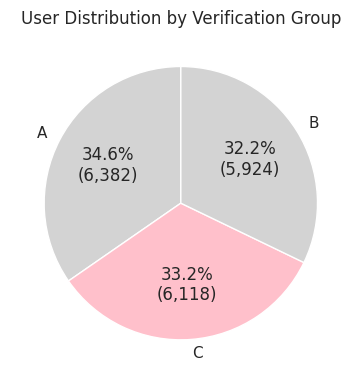

In [ ]:
# Count of userID by group (To know each group user traffic)
user_count_by_group = (
    final_df.groupby('group')['userID']
    .count()
    .reset_index(name='User_Count')
    .assign(Percentage=lambda df: (df['User_Count']/df['User_Count'].sum()*100).round(2))
    .sort_values(by='User_Count', ascending=False)
)

display(user_count_by_group)

#Pie
plt.figure(figsize=(5,4));
plt.pie(user_count_by_group['User_Count'], labels=user_count_by_group['group'], autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*user_count_by_group['User_Count'].sum())):,})", colors=['lightgrey', 'pink'], startangle=90);
plt.title('User Distribution by Verification Group');
plt.tight_layout();
plt.show()

,method,User_Count,Percentage
0,Sms,13852,75.18
1,Whatsapp,4572,24.82


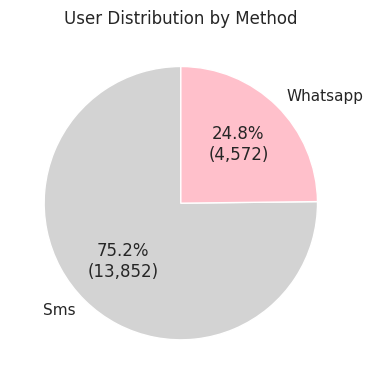

In [ ]:
# How each traffic is distributed along each method
user_count_by_method = (
    final_df.groupby('method')['userID']
    .count()
    .reset_index(name='User_Count')
    .assign(Percentage=lambda df: (df['User_Count']/df['User_Count'].sum()*100).round(2))
    .sort_values(by='User_Count', ascending=False)
)

display(user_count_by_method)

# Display Traffic distribution
plt.figure(figsize=(5,4));
plt.pie(user_count_by_method['User_Count'], labels=user_count_by_method['method'], autopct=lambda pct: f"{pct:.1f}%\n({int(round(pct/100.*user_count_by_method['User_Count'].sum())):,})", colors=['lightgrey', 'pink'], startangle=90, pctdistance=0.6);
plt.title('User Distribution by Method');
plt.tight_layout();
plt.show()

**Verification Conversion Rate** :


,group,User_Count,Verified_Count,Verified_Conversion_Rate (%)
0,A,6382,5573,87.32
1,B,5924,5498,92.81
2,C,6118,5679,92.82


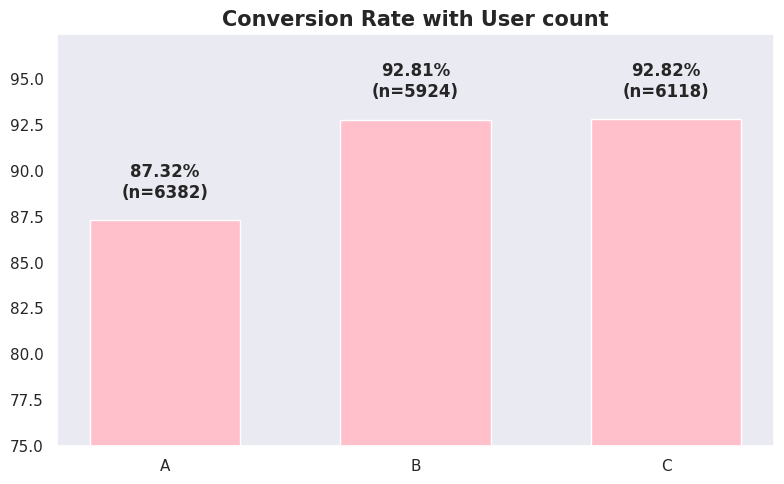

In [ ]:
#Conversion Rate with User count by group

pivot_table = (
    final_df.assign(verified=final_df['verified'].astype(int))
    .groupby('group')
    .agg(
        User_Count=('userID','count'),
        Verified_Count=('verified','sum')
    )
    .reset_index()
    .assign(**{'Verified_Conversion_Rate (%)': lambda x: (x['Verified_Count']/x['User_Count']*100).round(2)})
)

display(pivot_table)

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(pivot_table['group'], pivot_table['Verified_Conversion_Rate (%)'], width=0.6, color='pink')
ax.set_ylim(bottom=75)

for bar, rate, count in zip(bars, pivot_table['Verified_Conversion_Rate (%)'], pivot_table['User_Count']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1, f"{rate:.2f}%\n(n={count})", ha='center', va='bottom', fontweight='bold')
ax.grid(False)
plt.title('Conversion Rate with User count', fontweight='bold', fontsize='15');
plt.tight_layout()
plt.show()

,group,sms_usd,whatsapp_usd,total_avg,Verified_Conversion_Rate (%)
0,A,0.101042,NaN,NaN,87.32
1,B,0.09886,0.041445,0.070152,92.81
2,C,0.080161,0.043721,0.061941,92.82


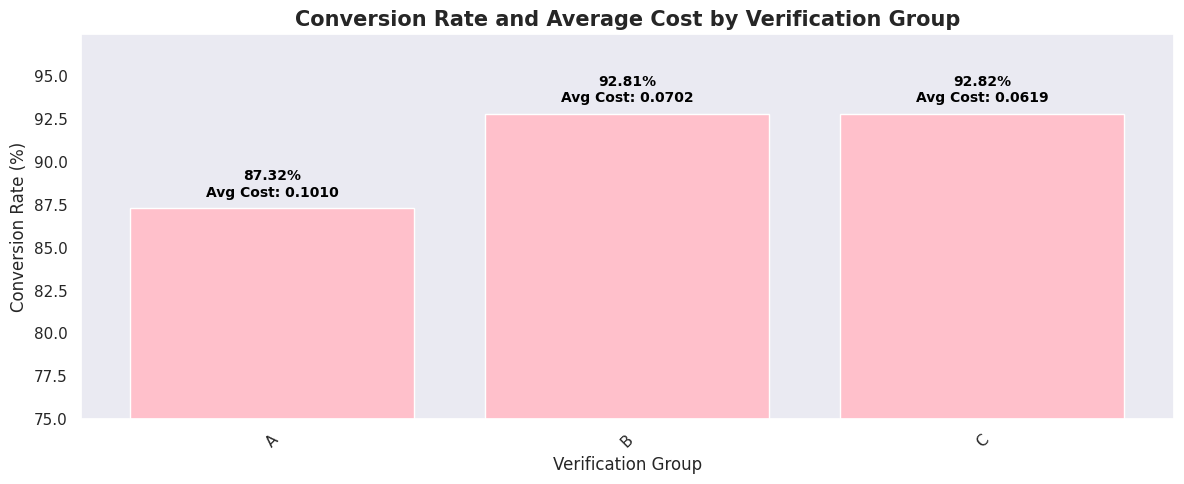

In [ ]:
#Conversion Rate and Average Cost by Verification Group

avg_cost_by_group = (
    filtered_df.groupby('group')[['sms_usd', 'whatsapp_usd']]
    .mean()
    .reset_index()
    .sort_values(by='sms_usd', ascending=False)
)


# Calculate total average cost
avg_cost_by_group['total_avg'] = (
    avg_cost_by_group['sms_usd'] + avg_cost_by_group['whatsapp_usd']
) / 2

# Merge with conversion rate
merged_for_plot = avg_cost_by_group.merge(
    pivot_table[['group', 'Verified_Conversion_Rate (%)']],
    on='group',
    how='left'
)

display(merged_for_plot)

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    merged_for_plot['group'],
    merged_for_plot['Verified_Conversion_Rate (%)'],
    color='pink'
)

# Y-axis now ONLY based on cost
ax.set_title('Conversion Rate and Average Cost by Verification Group', fontweight='bold', fontsize='15')
ax.set_xlabel('Verification Group')
ax.set_ylabel('Conversion Rate (%)')
ax.set_ylim(bottom=75)

# Add labels (cost + conversion rate together, tied to bar height)
for bar, conversion_rate, total_avg, sms_usd_val in zip(
    bars,
    merged_for_plot['Verified_Conversion_Rate (%)'],
    merged_for_plot['total_avg'],
    merged_for_plot['sms_usd'] # Add sms_usd to the zip for conditional display
):
    # Choose to display sms_usd if total_avg is NaN, otherwise total_avg
    avg_cost_display = sms_usd_val if np.isnan(total_avg) else total_avg

    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.5,  # small offset above bar
        f'{conversion_rate:.2f}%\nAvg Cost: {avg_cost_display:.4f}', # Display both conversion rate and conditional average cost
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color='black'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

,group,sms_usd,whatsapp_usd,total_avg,Verified_Conversion_Rate (%)
0,A,0.101042,NaN,NaN,87.32
1,B,0.09886,0.041445,0.070152,92.81
2,C,0.080161,0.043721,0.061941,92.82


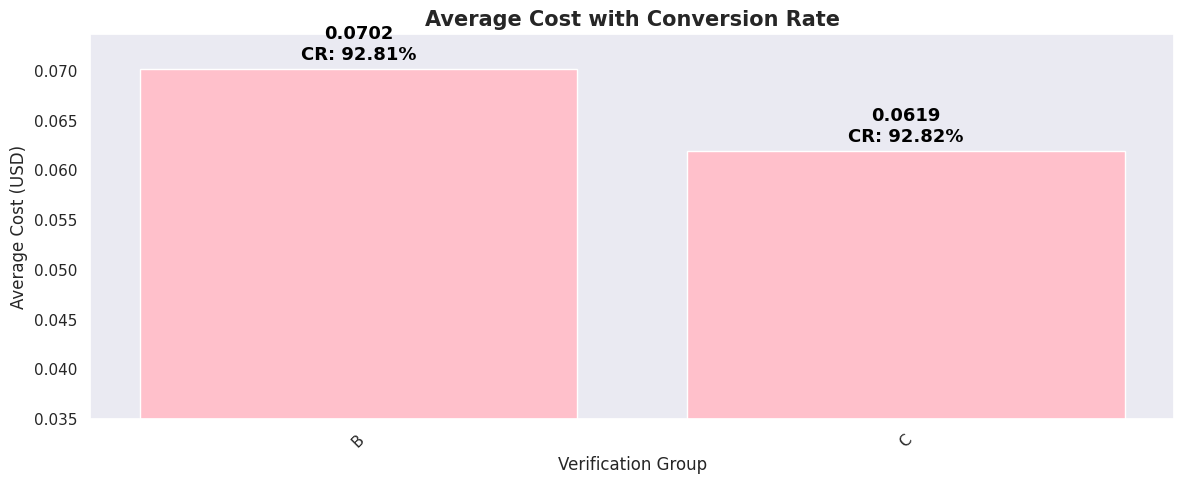

In [ ]:
#Average Cost with Conversion Rate

avg_cost_by_group = (
    filtered_df.groupby('group')[['sms_usd', 'whatsapp_usd']]
    .mean()
    .reset_index()
    .sort_values(by='sms_usd', ascending=False)
)


# Calculate total average cost
avg_cost_by_group['total_avg'] = (
    avg_cost_by_group['sms_usd'] + avg_cost_by_group['whatsapp_usd']
) / 2

# Merge with conversion rate
merged_for_plot = avg_cost_by_group.merge(
    pivot_table[['group', 'Verified_Conversion_Rate (%)']],
    on='group',
    how='left'
)

display(merged_for_plot)

fig, ax = plt.subplots(figsize=(12,5))

bars = ax.bar(
    merged_for_plot['group'],
    merged_for_plot['total_avg'],
    color='pink'
)

# Y-axis now ONLY based on cost
ax.set_title('Average Cost with Conversion Rate', fontweight='bold', fontsize='15')
ax.set_xlabel('Verification Group')
ax.set_ylabel('Average Cost (USD)')
ax.set_ylim(bottom=0.035)

# Add labels (cost + conversion rate together, tied to bar height)
for bar, total_avg, conversion_rate in zip(
    bars,
    merged_for_plot['total_avg'],
    merged_for_plot['Verified_Conversion_Rate (%)']
):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.0005,  # small offset above bar
        f'{total_avg:.4f}\nCR: {conversion_rate:.2f}%',
        ha='center',
        va='bottom',
        fontsize=13,
        fontweight='bold',
        color='black'
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.grid(False)
plt.show()

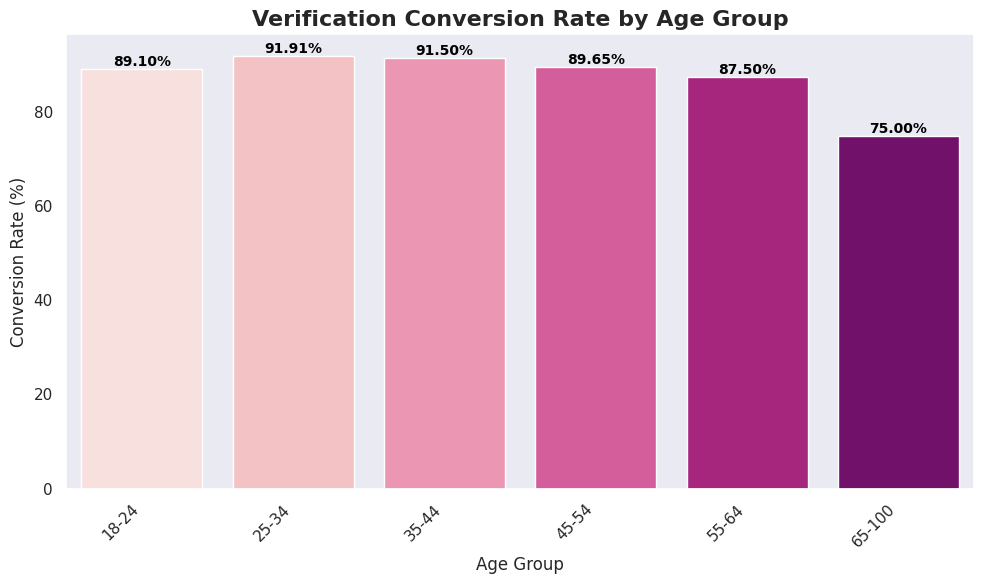

In [ ]:
# Calculate conversion rate by age group
age_group_conversion_rate = (
    final_df.assign(verified=final_df['verified'].astype(int))
    .groupby('age_group', observed=False)
    .agg(
        User_Count=('userID','count'),
        Verified_Count=('verified','sum')
    )
    .reset_index()
    .assign(**{'Verified_Conversion_Rate (%)': lambda x: (x['Verified_Count']/x['User_Count']*100).round(2)})
)

plt.figure(figsize=(10, 6));
ax = sns.barplot(
    x='age_group',
    y='Verified_Conversion_Rate (%)',
    data=age_group_conversion_rate,
    hue='age_group', palette='RdPu', legend=False
);

# Add data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', color='black', fontsize=10, fontweight='bold');

plt.title('Verification Conversion Rate by Age Group', fontsize=16, fontweight='bold');
plt.xlabel('Age Group', fontsize=12);
plt.ylabel('Conversion Rate (%)', fontsize=12);
plt.xticks(rotation=45, ha='right');
ax.grid(False);
plt.tight_layout();
plt.show();

In [ ]:
# Calculate conversion rate by age group and verification group
age_group_and_group_conversion_rate = (
    final_df.assign(verified=final_df['verified'].astype(int))
    .groupby(['age_group', 'group'], observed=False)
    .agg(
        User_Count=('userID','count'),
        Verified_Count=('verified','sum')
    )
    .reset_index()
    .assign(**{'Verified_Conversion_Rate (%)': lambda x: (x['Verified_Count']/x['User_Count']*100).round(2)})
)

pivot_conversion_rate_by_age_group_and_group = pd.pivot_table(age_group_and_group_conversion_rate,
                                                               index='age_group',
                                                               columns='group',
                                                               values='Verified_Conversion_Rate (%)')

print("Verified Conversion Rate (%) by Age Group and Verification Group:")
display(pivot_conversion_rate_by_age_group_and_group)

Verified Conversion Rate (%) by Age Group and Verification Group:


/tmp/ipykernel_6691/3423616041.py:13: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_conversion_rate_by_age_group_and_group = pd.pivot_table(age_group_and_group_conversion_rate,


group,A,B,C
age_group,,,
18-24,84.93,91.31,91.24
25-34,88.48,93.87,93.61
35-44,88.54,92.86,93.35
45-54,86.02,90.72,92.15
55-64,79.25,94.87,90.00
65-100,70.00,66.67,85.71


In [ ]:
#Top 10 Countries by Users Count Conversion Rate

from IPython.display import Markdown

# Step 1: Base aggregation
conversion_rate_by_country_and_group = (
    final_df
    .assign(verified=final_df['verified'].astype(int))
    .groupby(['country', 'group'])
    .agg(
        User_Count=('userID','count'),
        Verified_Count=('verified','sum')
    )
    .assign(
        **{'Verified_Conversion_Rate (%)': lambda x: (x['Verified_Count'] / x['User_Count'] * 100).round(2)}
    )
    .reset_index()
)

# Step 2: Pivot conversion rates only
pivot_conversion_rate = (
    conversion_rate_by_country_and_group
    .pivot(index='country', columns='group', values='Verified_Conversion_Rate (%)')
)

# Step 3: Rename pivoted columns to be explicit
pivot_conversion_rate.columns = [
    f"Verified_Conversion_Rate (%)_{col}" for col in pivot_conversion_rate.columns
]

# Step 4: Total users per country (NOT split by group)
country_user_count = (
    final_df
    .groupby('country')['userID']
    .count()
    .rename('Total_User_Count')
)

# Step 5: Merge together
final_output = pivot_conversion_rate.merge(country_user_count, on='country')

# Step 6: Sort by Total_User_Count descending
final_output = final_output.sort_values('Total_User_Count', ascending=False)

# Display final, sorted table
display(Markdown("##  Top 10 Countries by Users Count Conversion Rate"))
display(final_output.head(10))

##  Top 10 Countries by Users Count Conversion Rate

,Verified_Conversion_Rate (%)_A,Verified_Conversion_Rate (%)_B,Verified_Conversion_Rate (%)_C,Total_User_Count
country,,,,
MA,83.49,92.09,93.47,2037
FR,92.51,93.24,94.81,1589
PK,83.30,92.90,92.94,1570
US,90.27,93.91,93.89,1311
ID,81.47,94.31,91.94,1162
EG,82.28,90.29,90.51,1128
GB,91.75,93.70,94.10,1110
DZ,86.19,91.27,90.44,719
DE,91.74,91.67,92.74,668
